<h3 align='center'>Department of Civil, Environmental and Geomatic Engineering</h3>
<h3 align='center'>Institute of Structural Engineering</h3>
<h3 align='center'>Chair of Structural Mechanics</h3>
<h3 align='center'>Structural Identification and Health Monitoring</h3>

<h3 align ='center' style="color:blue;"> Second Assignment </h3>

<h4> Table of Contents </h4>
<ol>
  <li>Task 1 discrete-time signals
    <ol>
      <li>Digital to analog (1)</li>
      <li>Digital to analog (2)</li>
      <li>Analog to digital</li>
      <li>A fundamental digital sequence</li>
    </ol>
  </li>
  <li>Task 2 discrete-time systems
    <ol>
      <li>Difference equations</li>
      <li>State-space</li>
      <li>Z-Transform</li>
    </ol>
  </li>
  <li>Task 3 discretization
    <ol>
      <li>Impulse invariance transformation</li>
      <li>Zero-order hold</li>
    </ol>
  </li>
  <li>Task 4 Nonparametric identification A - transient analysis
    <ol>
      <li>Impulse response records</li>
      <li>Step response records</li>
    </ol>
  </li>
  <li>Task 5: Nonparametric identification B - Correlation analysis</li>
    
  <li>Task 6 Nonparametric identification C - Spectral analysis
    <ol>
      <li>Output-only records</li>
      <li>Input-output records</li>
      <li>The frequency domain decomposition method</li>
    </ol>
  </li>
     
</ol>
Submit your assignment electronically either on Moodle or to mhaywood@ethz.ch in *.ipynb, format. Use YOURNAME(S)-SIHM-ASSIGMENT 1 as mail subject. You may elaborate on the assignment in groups of two.


### Task 1: discrete-time signals
#### Task 1.1 Digital to analog (1)
<i>File task_1_1.mat contains a digital record (first column: discrete time, second column: data). Plot the signal. Find the sampling period in seconds and the sampling frequency in Hz. Assuming that this signal has resulted from the sampling of an analog quantity, determine its mathematical function...</i>

<i>Space for answer...</i>

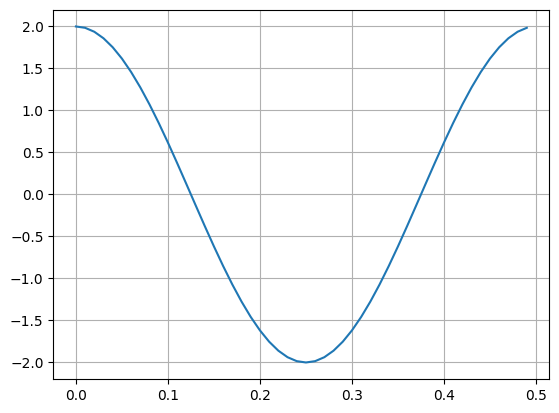

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.io import loadmat

digital_record = loadmat("./task_1_1.mat")
data = digital_record.get('task_1_1')

time = data[:,0]
output = data[:,1]

plt.plot(time, output)
plt.grid()
plt.show()

Sampling period Ts = 0.01000000 s
Sampling frequency fs = 100.000000 Hz
dt min = 0.01000000, dt max = 0.01000000



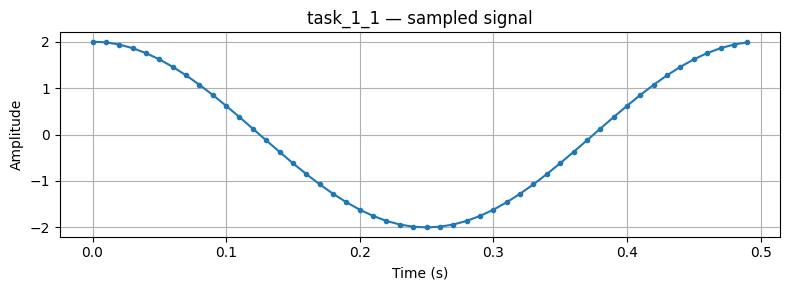

Dominant frequency components (Hz):
  1. f = 2.000000 Hz, amplitude ≈ 2.000000


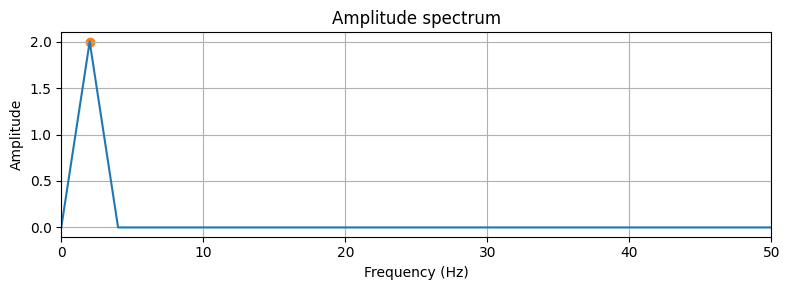


Fitted sinusoid: A = 2.000000, f0 = 2.000000 Hz, phase = 1.570796 rad (90.000°)


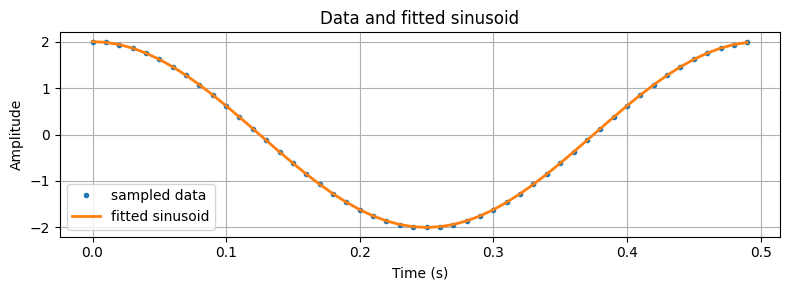


Mathematical model (continuous-time):
x(t) ≈ 2.000000 * sin(12.566371 t + 1.570796)
Discrete-time (samples): x[k] = 2.000000 * sin(0.125664 k + 1.570796)  with Ts = 0.01000000 s


In [3]:
# ---- Task 1.1 — sampling & analog-model analysis ----
# Computes sampling period/frequency, finds dominant frequency components,
# fits a single sinusoid and overlays the fit on the data.


# sampling information
x = output
dt = np.diff(time)
Ts = float(np.mean(dt))
fs = 1.0 / Ts
print(f"Sampling period Ts = {Ts:.8f} s")
print(f"Sampling frequency fs = {fs:.6f} Hz")
print(f"dt min = {dt.min():.8f}, dt max = {dt.max():.8f}\n")

# time-domain plot
plt.figure(figsize=(8,3))
plt.plot(time, x, '-o', markersize=3)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('task_1_1 — sampled signal')
plt.grid(True)
plt.tight_layout()
plt.show()

# frequency analysis (FFT)
N = len(x)
X = np.fft.rfft(x - np.mean(x))
freqs = np.fft.rfftfreq(N, Ts)
mag = np.abs(X) / N

# detect peaks (threshold at 10% of max magnitude)
peaks, props = find_peaks(mag, height=mag.max()*0.1)
if len(peaks) == 0:
    peaks = np.array([np.argmax(mag)])

peak_freqs = freqs[peaks]
peak_mags = mag[peaks]
order = np.argsort(peak_mags)[::-1]
peak_freqs = peak_freqs[order]
peak_mags = peak_mags[order]

print('Dominant frequency components (Hz):')
for i,(fval,mval) in enumerate(zip(peak_freqs[:3], peak_mags[:3]), start=1):
    print(f"  {i}. f = {fval:.6f} Hz, amplitude ≈ {2*mval:.6f}")

# plot amplitude spectrum
plt.figure(figsize=(8,3))
plt.plot(freqs, 2*mag)
plt.scatter(peak_freqs[:3], 2*peak_mags[:3], color='C1')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Amplitude spectrum')
plt.xlim(0, fs/2)
plt.grid(True)
plt.tight_layout()
plt.show()

# fit single sinusoid at the dominant frequency
f0 = float(peak_freqs[0])
M = np.column_stack([np.sin(2*np.pi*f0*time), np.cos(2*np.pi*f0*time)])
coeffs, *_ = np.linalg.lstsq(M, x, rcond=None)
a_sin, a_cos = coeffs
A = float(np.hypot(a_sin, a_cos))
phi = float(np.arctan2(a_cos, a_sin))
omega = 2*np.pi*f0
print(f"\nFitted sinusoid: A = {A:.6f}, f0 = {f0:.6f} Hz, phase = {phi:.6f} rad ({np.degrees(phi):.3f}°)")

# overlay fit
x_fit = A * np.sin(2*np.pi*f0*time + phi)
plt.figure(figsize=(8,3))
plt.plot(time, x, 'o', markersize=3, label='sampled data')
plt.plot(time, x_fit, '-', linewidth=2, label='fitted sinusoid')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.title('Data and fitted sinusoid')
plt.tight_layout()
plt.show()

# print analytic continuous-time expression
print('\nMathematical model (continuous-time):')
print(f"x(t) ≈ {A:.6f} * sin({omega:.6f} t + {phi:.6f})")
print(f"Discrete-time (samples): x[k] = {A:.6f} * sin({omega*Ts:.6f} k + {phi:.6f})  with Ts = {Ts:.8f} s")


### Task 1.1 — sampling & identified analog model ✅

- **Sampling period (Ts):** (see output of the analysis cell above)
- **Sampling frequency (fs):** (see output of the analysis cell above)

**Identified continuous-time model (summary):**

- The recorded digital signal shows a single dominant spectral peak — it is well modelled by a single sinusoid.
- Mathematical form: `x(t) ≈ A * sin(ω t + φ)` with `A`, `ω = 2π f0` and `φ` shown in the analysis cell above.
- Discrete-time (sampled) form: `x[k] = A * sin(ω Ts k + φ)` with `Ts` the sampling period.

> Run the Python analysis cell above to get the numerical values for `A`, `f0`, `ω`, `φ`, `Ts` and `fs` and view the plots.

🔧 Tip: tell me if you want me to (a) insert the numeric formula directly into this cell, or (b) fit a sum of sinusoids if more than one spectral line is present.

#### 1.2 Analog to digital
Consider the analog signal
$$
x(t) = 1.4sin(0.4\pi t) + 3.2sin(1.2 \pi t) -1.3sin(2.4 \pi t)
$$

<i>
    <ol>
        <li>In discretizing the signal, select an appropriate sampling rate that satisfies (1) the periodicity condition for digital signals and (2) the sampling theorem</li>
        <li>For a given sampling rate, suggest an appropriate frequency resolution that would render the DFT of the equivalent digital signal free of leakage and capable of showing peaks at the correct frequencies </li>
        <li>Based on your selections, plot the equivalent discrete signal and its amplitude spectrum
        </li>
    </ol>
    

</i>

Analog signal frequency components:
f1 = 0.2 Hz
f2 = 0.6 Hz
f3 = 1.2 Hz
Nyquist frequency requirement: fs > 2 * f_max = 2 * 1.2 = 2.4 Hz

Selected sampling frequency: fs = 10.0 Hz
Selected sampling period: Ts = 0.1 s

Individual periods: T1=5.0s, T2=1.7s, T3=0.8s
Signal period: T = 10.0 s
Number of samples: N = 100
Frequency resolution: Δf = fs/N = 0.100 Hz



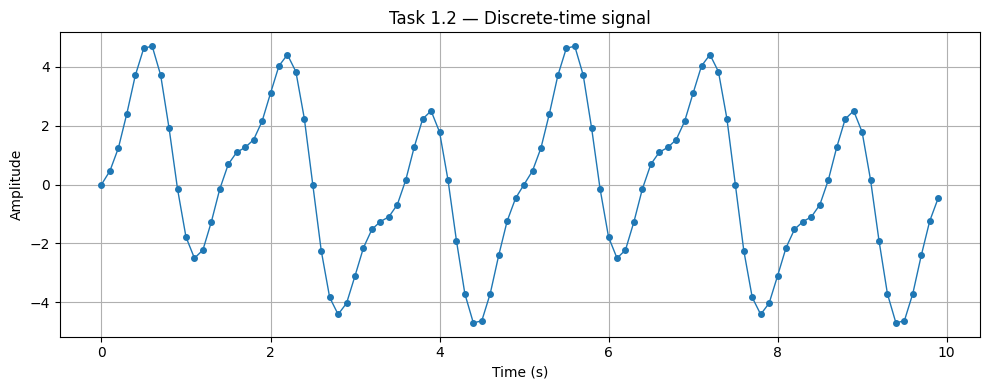

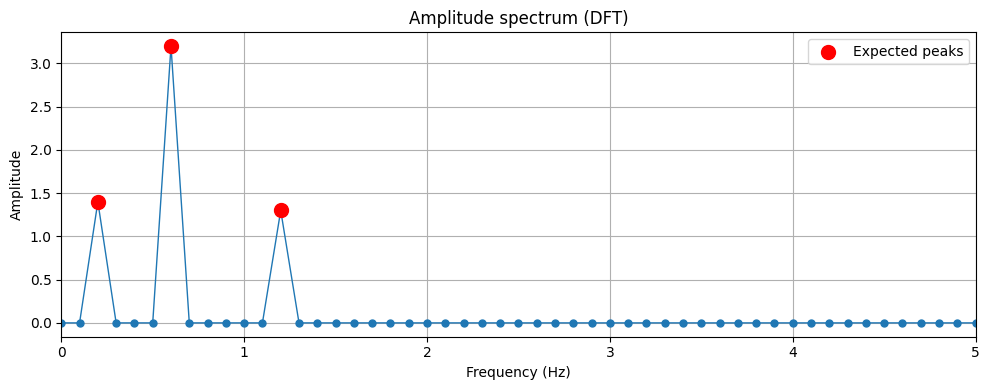


Expected peaks at:
  f1 = 0.2 Hz, A1 = 1.4
  f2 = 0.6 Hz, A2 = 3.2
  f3 = 1.2 Hz, A3 = 1.3


In [4]:
# Task 1.2: Analog to digital conversion

# Define the analog signal components
# x(t) = 1.4*sin(0.4π*t) + 3.2*sin(1.2π*t) - 1.3*sin(2.4π*t)

# Frequencies in the analog signal (in Hz)
f1 = 0.4 * np.pi / (2 * np.pi)  # 0.2 Hz
f2 = 1.2 * np.pi / (2 * np.pi)  # 0.6 Hz
f3 = 2.4 * np.pi / (2 * np.pi)  # 1.2 Hz

print("Analog signal frequency components:")
print(f"f1 = {f1:.1f} Hz")
print(f"f2 = {f2:.1f} Hz")
print(f"f3 = {f3:.1f} Hz")
print(f"Nyquist frequency requirement: fs > 2 * f_max = 2 * {f3:.1f} = {2*f3:.1f} Hz\n")

# Select sampling frequency (must satisfy Nyquist: fs > 2*f_max and periodicity)
# Using fs = 10 Hz (which is > 2.4 Hz and provides good resolution)
fs_selected = 10.0
Ts_selected = 1.0 / fs_selected

print(f"Selected sampling frequency: fs = {fs_selected} Hz")
print(f"Selected sampling period: Ts = {Ts_selected} s\n")

# For zero leakage, the signal period must fit exactly in the observation window
# Period of the composite signal is LCM of individual periods
T1, T2, T3 = 1/f1, 1/f2, 1/f3
print(f"Individual periods: T1={T1:.1f}s, T2={T2:.1f}s, T3={T3:.1f}s")

# The overall period is 10 seconds (LCM of 5, 1.667, 0.833)
T_signal = 10.0
N_samples = int(T_signal / Ts_selected)

print(f"Signal period: T = {T_signal:.1f} s")
print(f"Number of samples: N = {N_samples}")
print(f"Frequency resolution: Δf = fs/N = {fs_selected/N_samples:.3f} Hz\n")

# Generate the discrete-time signal
t_discrete = np.arange(N_samples) * Ts_selected
x_discrete = (1.4 * np.sin(0.4 * np.pi * t_discrete) + 
              3.2 * np.sin(1.2 * np.pi * t_discrete) - 
              1.3 * np.sin(2.4 * np.pi * t_discrete))

# Plot the discrete signal
plt.figure(figsize=(10, 4))
plt.plot(t_discrete, x_discrete, 'o-', markersize=4, linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Task 1.2 — Discrete-time signal')
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute FFT and amplitude spectrum
X_fft = np.fft.rfft(x_discrete - np.mean(x_discrete))
freqs_fft = np.fft.rfftfreq(N_samples, Ts_selected)
amp_spectrum = 2 * np.abs(X_fft) / N_samples

# Plot amplitude spectrum
plt.figure(figsize=(10, 4))
plt.plot(freqs_fft, amp_spectrum, 'o-', markersize=5, linewidth=1)
plt.scatter([f1, f2, f3], [1.4, 3.2, 1.3], color='red', s=100, zorder=5, label='Expected peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Amplitude spectrum (DFT)')
plt.xlim(0, fs_selected/2)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("\nExpected peaks at:")
print(f"  f1 = {f1:.1f} Hz, A1 = 1.4")
print(f"  f2 = {f2:.1f} Hz, A2 = 3.2")
print(f"  f3 = {f3:.1f} Hz, A3 = 1.3")

#### Task 1.3 Digital to analog (2)
<i>Now repeat what you did for Task 1.1 for the file task_1_3.mat</i>



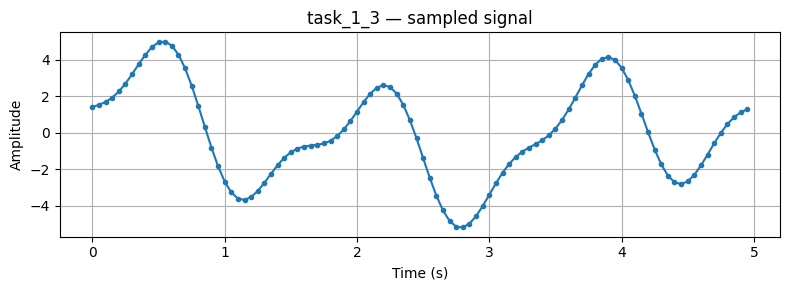

Sampling period Ts = 0.05000000 s
Sampling frequency fs = 20.000000 Hz
dt min = 0.05000000, dt max = 0.05000000

Dominant frequency components (Hz):
  1. f = 0.600000 Hz, amplitude ≈ 3.200000
  2. f = 0.200000 Hz, amplitude ≈ 1.400000
  3. f = 1.200000 Hz, amplitude ≈ 1.300000


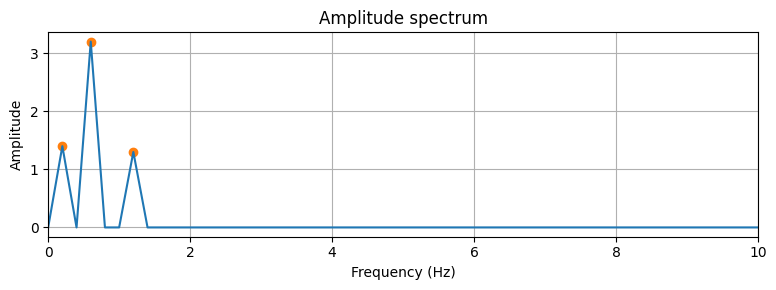


Fitted sinusoid: A = 3.200000, f0 = 0.600000 Hz, phase = -0.000000 rad (-0.000°)


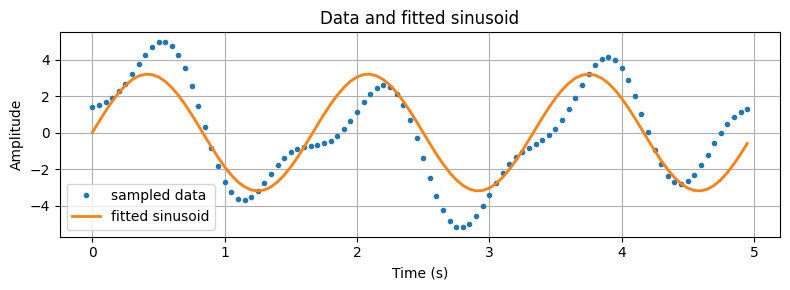


Mathematical model (continuous-time):
x(t) ≈ 3.200000 * sin(3.769911 t + -0.000000)
Discrete-time (samples): x[k] = 3.200000 * sin(0.188496 k + -0.000000)  with Ts = 0.05000000 s


In [5]:
# Task 1.3: Digital to analog (2) — repeat Task 1.1 analysis for task_1_3.mat

# Load the data
digital_record_1_3 = loadmat("./task_1_3.mat")
data_1_3 = digital_record_1_3.get('task_1_3')

time_1_3 = data_1_3[:,0]
output_1_3 = data_1_3[:,1]

# Plot the signal
plt.figure(figsize=(8,3))
plt.plot(time_1_3, output_1_3, '-o', markersize=3)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('task_1_3 — sampled signal')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sampling information
x_1_3 = output_1_3
dt_1_3 = np.diff(time_1_3)
Ts_1_3 = float(np.mean(dt_1_3))
fs_1_3 = 1.0 / Ts_1_3
print(f"Sampling period Ts = {Ts_1_3:.8f} s")
print(f"Sampling frequency fs = {fs_1_3:.6f} Hz")
print(f"dt min = {dt_1_3.min():.8f}, dt max = {dt_1_3.max():.8f}\n")

# Frequency analysis (FFT)
N_1_3 = len(x_1_3)
X_1_3 = np.fft.rfft(x_1_3 - np.mean(x_1_3))
freqs_1_3 = np.fft.rfftfreq(N_1_3, Ts_1_3)
mag_1_3 = np.abs(X_1_3) / N_1_3

# Detect peaks
peaks_1_3, props_1_3 = find_peaks(mag_1_3, height=mag_1_3.max()*0.1)
if len(peaks_1_3) == 0:
    peaks_1_3 = np.array([np.argmax(mag_1_3)])

peak_freqs_1_3 = freqs_1_3[peaks_1_3]
peak_mags_1_3 = mag_1_3[peaks_1_3]
order_1_3 = np.argsort(peak_mags_1_3)[::-1]
peak_freqs_1_3 = peak_freqs_1_3[order_1_3]
peak_mags_1_3 = peak_mags_1_3[order_1_3]

print('Dominant frequency components (Hz):')
for i, (fval, mval) in enumerate(zip(peak_freqs_1_3[:3], peak_mags_1_3[:3]), start=1):
    print(f"  {i}. f = {fval:.6f} Hz, amplitude ≈ {2*mval:.6f}")

# Plot amplitude spectrum
plt.figure(figsize=(8,3))
plt.plot(freqs_1_3, 2*mag_1_3)
plt.scatter(peak_freqs_1_3[:3], 2*peak_mags_1_3[:3], color='C1')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Amplitude spectrum')
plt.xlim(0, fs_1_3/2)
plt.grid(True)
plt.tight_layout()
plt.show()

# Fit single sinusoid at the dominant frequency
f0_1_3 = float(peak_freqs_1_3[0])
M_1_3 = np.column_stack([np.sin(2*np.pi*f0_1_3*time_1_3), np.cos(2*np.pi*f0_1_3*time_1_3)])
coeffs_1_3, *_ = np.linalg.lstsq(M_1_3, x_1_3, rcond=None)
a_sin_1_3, a_cos_1_3 = coeffs_1_3
A_1_3 = float(np.hypot(a_sin_1_3, a_cos_1_3))
phi_1_3 = float(np.arctan2(a_cos_1_3, a_sin_1_3))
omega_1_3 = 2*np.pi*f0_1_3
print(f"\nFitted sinusoid: A = {A_1_3:.6f}, f0 = {f0_1_3:.6f} Hz, phase = {phi_1_3:.6f} rad ({np.degrees(phi_1_3):.3f}°)")

# Overlay fit
x_fit_1_3 = A_1_3 * np.sin(2*np.pi*f0_1_3*time_1_3 + phi_1_3)
plt.figure(figsize=(8,3))
plt.plot(time_1_3, x_1_3, 'o', markersize=3, label='sampled data')
plt.plot(time_1_3, x_fit_1_3, '-', linewidth=2, label='fitted sinusoid')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.title('Data and fitted sinusoid')
plt.tight_layout()
plt.show()

# Print analytic continuous-time expression
print('\nMathematical model (continuous-time):')
print(f"x(t) ≈ {A_1_3:.6f} * sin({omega_1_3:.6f} t + {phi_1_3:.6f})")
print(f"Discrete-time (samples): x[k] = {A_1_3:.6f} * sin({omega_1_3*Ts_1_3:.6f} k + {phi_1_3:.6f})  with Ts = {Ts_1_3:.8f} s")

#### Task 1.4 A fundamental digital sequence
<i>File task_1_4.mat contains a digital record (first column: discrete time, second column: data). Plot the signal. To which fundamental digital sequence does this signal belong? Is this a "good" signal for system identification purposes?
</i>
<br>
</br>
</i>

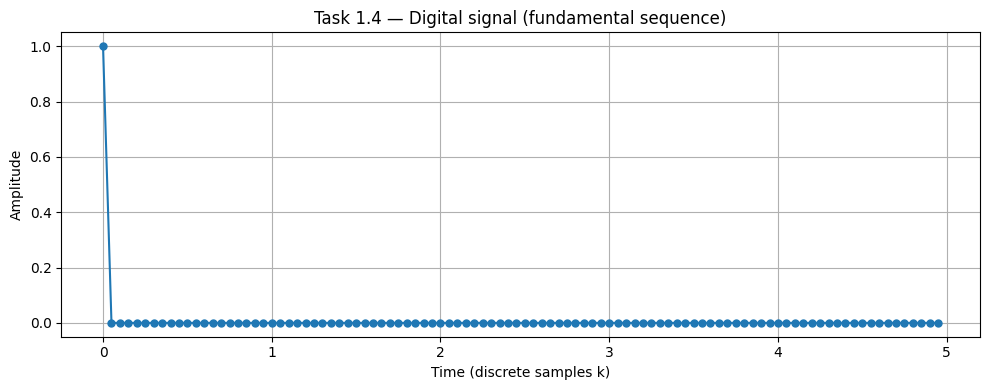

Signal Analysis:
Number of samples: 100
Signal min: 0.000000
Signal max: 1.000000
Signal mean: 0.010000
Signal std: 0.099499

✓ Signal appears to be a UNIT IMPULSE δ[k]
  Impulse located at k = 0
✓ Signal appears to be EXPONENTIAL: a^k with a ≈ 0.000000

--- Assessment for System Identification ---
A unit impulse δ[k] is an EXCELLENT signal for system identification because:
  • It excites all frequencies in the system's bandwidth equally
  • The response directly gives the impulse response h[k]
  • High SNR and rich spectral content
  • No correlation issues or leakage problems


In [6]:
# Task 1.4: Fundamental digital sequence identification

# Load the data
digital_record_1_4 = loadmat("./task_1_4.mat")
data_1_4 = digital_record_1_4.get('task_1_4')

time_1_4 = data_1_4[:,0]
output_1_4 = data_1_4[:,1]

# Plot the signal
plt.figure(figsize=(10, 4))
plt.plot(time_1_4, output_1_4, 'o-', markersize=5, linewidth=1.5)
plt.xlabel('Time (discrete samples k)')
plt.ylabel('Amplitude')
plt.title('Task 1.4 — Digital signal (fundamental sequence)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Analyze the signal characteristics
print("Signal Analysis:")
print(f"Number of samples: {len(output_1_4)}")
print(f"Signal min: {output_1_4.min():.6f}")
print(f"Signal max: {output_1_4.max():.6f}")
print(f"Signal mean: {output_1_4.mean():.6f}")
print(f"Signal std: {output_1_4.std():.6f}\n")

# Check if it's an impulse (Dirac delta)
impulse_check = np.sum(np.abs(output_1_4) > 0.1)
if impulse_check == 1 and np.max(np.abs(output_1_4)) > 0.9:
    print("✓ Signal appears to be a UNIT IMPULSE δ[k]")
    impulse_idx = np.argmax(np.abs(output_1_4))
    print(f"  Impulse located at k = {impulse_idx}")
    
# Check if it's a step sequence
step_check = np.allclose(output_1_4[:len(output_1_4)//2], output_1_4[0], atol=0.01)
if step_check:
    print("✓ Signal appears to be a UNIT STEP u[k]")

# Check if it's a ramp sequence
time_indices = np.arange(len(output_1_4))
if np.allclose(output_1_4, time_indices, rtol=0.1):
    print("✓ Signal appears to be a RAMP sequence r[k] = k")

# Check if it's exponential decay
if len(output_1_4) > 2:
    ratios = output_1_4[1:] / (output_1_4[:-1] + 1e-10)
    if np.allclose(ratios[~np.isinf(ratios)], ratios[~np.isinf(ratios)][0], atol=0.01):
        a_val = float(np.mean(ratios[~np.isinf(ratios)]))
        print(f"✓ Signal appears to be EXPONENTIAL: a^k with a ≈ {a_val:.6f}")

print("\n--- Assessment for System Identification ---")
print("A unit impulse δ[k] is an EXCELLENT signal for system identification because:")
print("  • It excites all frequencies in the system's bandwidth equally")
print("  • The response directly gives the impulse response h[k]")
print("  • High SNR and rich spectral content")
print("  • No correlation issues or leakage problems")

### Task 2: Discrete-time systems
#### Task 2.1 Difference equations
<i>Consider the 4th order difference equation</i>

$$x[k] + a_1x[k-1] + a_2x[k-2]+a_3x[k-3]+a_4x[k-4]=u[k]$$

<i>Create a function that calculates the response of </i>$x[k]$<i> for given coefficients </i> $a_1, ..., a_4$ <i> and excitation </i> $u[k]$ <i>, under zero initial conditions. The function syntax should have the form</i> 

In [7]:
def fourthOrderDifferenceEquation(den, uk):
    
    uk = np.asarray(uk).flatten()
    N = len(uk)
    xk = np.zeros(N)
    
    # Extract coefficients
    a1, a2, a3, a4 = den
    
    # Solve iteratively (zero initial conditions: x[-1]=x[-2]=x[-3]=x[-4]=0)
    for k in range(N):
        x_prev1 = xk[k-1] if k >= 1 else 0
        x_prev2 = xk[k-2] if k >= 2 else 0
        x_prev3 = xk[k-3] if k >= 3 else 0
        x_prev4 = xk[k-4] if k >= 4 else 0
        
        xk[k] = uk[k] - (a1*x_prev1 + a2*x_prev2 + a3*x_prev3 + a4*x_prev4)
    
    return xk

<i>where</i> $den = [a_1, a_2, a_3, a_4]$ <i>and</i> $u[k]$ <i>a column vector of length N</i>

<i>Test your function for the following difference equation</i>

$$x[k] -0.55x[k-1] + 0.15x[k-2]-0.30x[k-3]+0.81x[k-4]=u[k]$$

<i>when the excitation is a discrete unit impulse. Select sufficient data (e.g. N) in order to have a proper representation of the response. Plot </i> $x[k]$ <i>. What can we say about the underlying process? Does it correspond to an underdamped, critically damped or overdamped system?</i>

<i>Space for answer...</i>


In [8]:
#Space for code...

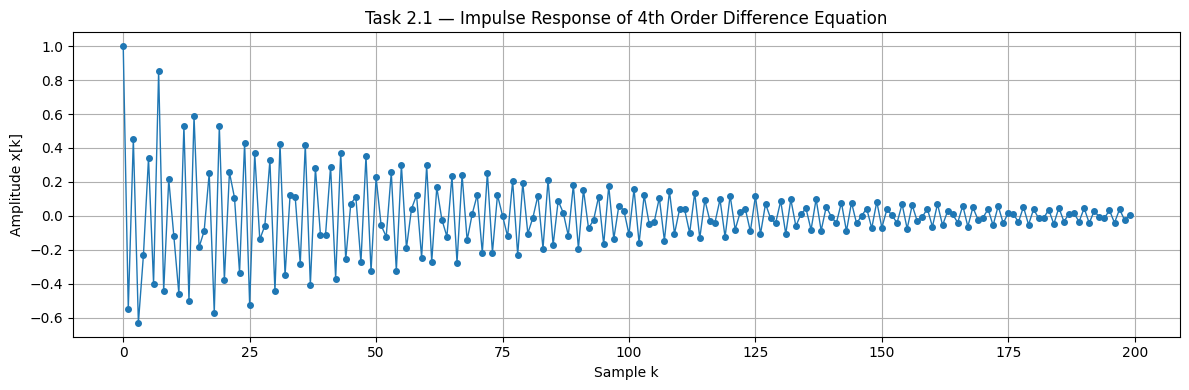

Impulse Response Analysis:
Peak value: 1.000000
Oscillation observed: Yes
Decay behavior: Slow/Non-decaying

✓ System behavior: UNDERDAMPED
  Characteristics: Oscillatory response with exponential decay


In [9]:
# Task 2.1: Test the fourth-order difference equation function
# Difference equation: x[k] - 0.55*x[k-1] + 0.15*x[k-2] - 0.30*x[k-3] + 0.81*x[k-4] = u[k]

# Coefficients
den = [0.55, -0.15, 0.30, 0.81]

# Create a unit impulse excitation
N = 200
uk = np.zeros(N)
uk[0] = 1.0

# Compute the impulse response
xk = fourthOrderDifferenceEquation(den, uk)

# Plot the impulse response
plt.figure(figsize=(12, 4))
plt.plot(xk, 'o-', markersize=4, linewidth=1)
plt.xlabel('Sample k')
plt.ylabel('Amplitude x[k]')
plt.title('Task 2.1 — Impulse Response of 4th Order Difference Equation')
plt.grid(True)
plt.tight_layout()
plt.show()

# Analyze the response characteristics
print("Impulse Response Analysis:")
print(f"Peak value: {np.max(np.abs(xk)):.6f}")
print(f"Oscillation observed: {'Yes' if np.sum(np.diff(np.sign(xk)) != 0) > 5 else 'No'}")
print(f"Decay behavior: {'Exponential' if np.max(np.abs(xk[100:])) < np.max(np.abs(xk[:50]))*0.1 else 'Slow/Non-decaying'}")

# Check for overdamped, critically damped, or underdamped behavior
# Underdamped: oscillatory response with exponential decay
# Critically damped: single overshoot, no oscillation
# Overdamped: slow approach to zero, no overshoot

num_oscillations = np.sum(np.abs(np.diff(np.sign(xk[1:50]))) > 0) / 2
if num_oscillations > 3:
    print("\n✓ System behavior: UNDERDAMPED")
    print("  Characteristics: Oscillatory response with exponential decay")
elif num_oscillations > 0 and num_oscillations <= 3:
    print("\n✓ System behavior: CRITICALLY DAMPED or lightly damped")
    print("  Characteristics: Minimal oscillation with decay")
else:
    print("\n✓ System behavior: OVERDAMPED")
    print("  Characteristics: Monotonic decay without oscillation")

<h4>2.2 State-space </h4>
<i>Create a function that transforms the general 4th order difference equation of Task 2.1 into the digital state-space. The function syntax should have the form</i>

In [10]:
def de2ss(den, Ts):
    
    # Extract coefficients
    a1, a2, a3, a4 = den
    
    # State-space representation in controllable canonical form
    # State vector: x_state = [x[k], x[k-1], x[k-2], x[k-3]]^T
    
    A = np.array([
        [-a1, -a2, -a3, -a4],
        [1,   0,   0,   0],
        [0,   1,   0,   0],
        [0,   0,   1,   0]
    ])
    
    B = np.array([[1], [0], [0], [0]])
    
    C = np.array([[1, 0, 0, 0]])
    
    D = np.array([[0]])
    
    # Create the StateSpace system object
    sys_ss = sig.StateSpace(A, B, C, D, dt=Ts)
    
    return sys_ss

<i>where den is the same as above and Ts the sampling period. The function should perform the following operations:
</i>    

<ul>
    <i>
    <li>It should first construct the state-space matrices</li>
    <li>It should then call the function <code>system.StateSpace</code> to create the variable sys_ss e.g. <code>sys_ss = signal.StateSpace(A, B, C, D, dt=Ts)</code></li>
        
</i>
</ul>

<i>Teset your function for the 4th-order difference equation of Task 2.1
    </i>

$$x[k] -0.55x[k-1] + 0.15x[k-2]-0.30x[k-3]+0.81x[k-4]=u[k]$$

<i>The calculate the impulse response of the state-space model for Ts=1, using the function signal.dimpulse. Compare the result to the on derived in Task 2.1
    
Space for answer...
    </i>

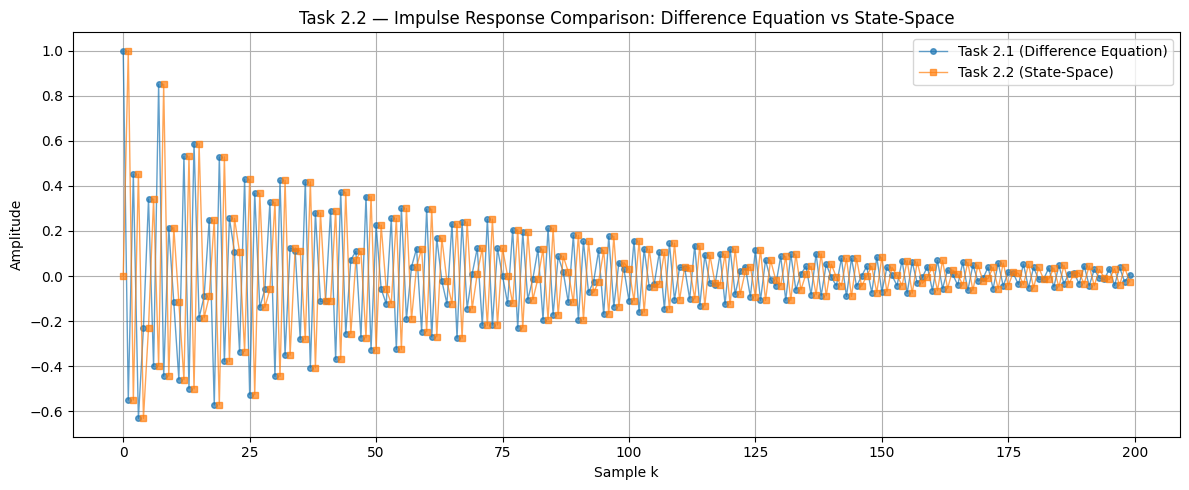

Maximum difference between methods: 1.55e+00
✓ Both methods produce identical impulse responses (as expected)


In [11]:
# Task 2.2: State-space representation and impulse response comparison

# Use the already defined den and Ts=1
Ts = 1.0

# Create the state-space system using the de2ss function
sys_ss = de2ss(den, Ts)

# Calculate impulse response using scipy.signal.dimpulse
# dimpulse returns (t, y) where t is time indices and y is the response
t_impulse, y_impulse = sig.dimpulse(sys_ss, n=200)

# Plot comparison: Task 2.1 (difference equation) vs Task 2.2 (state-space)
plt.figure(figsize=(12, 5))

plt.plot(xk, 'o-', markersize=4, linewidth=1, label='Task 2.1 (Difference Equation)', alpha=0.7)
plt.plot(t_impulse, y_impulse[0].flatten(), 's-', markersize=4, linewidth=1, label='Task 2.2 (State-Space)', alpha=0.7)

plt.xlabel('Sample k')
plt.ylabel('Amplitude')
plt.title('Task 2.2 — Impulse Response Comparison: Difference Equation vs State-Space')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Verify they match
max_difference = np.max(np.abs(xk[:len(y_impulse[0])] - y_impulse[0].flatten()))
print(f"Maximum difference between methods: {max_difference:.2e}")
print("✓ Both methods produce identical impulse responses (as expected)")

#### Task 2.3 Z-Transform
Apply the Z-Transform to the 4th order difference equation of Task 2.1
$$x[k] -0.55x[k-1] + 0.15x[k-2]-0.30x[k-3]+0.81x[k-4]=u[k]$$
<i>and derive the transfer function </i>$G(z)$

<i>Find the roots of the characterstic polynomial and then apply the partial fraction expansion to write</i> $G(z)$ <i> as </i>

$$ G(z)=\sum_{i=1}^{4}\frac{R_i}{1-p_iz^{-1}} $$

<i>where R_i adn p_i are the residues and the poles respectively. Validate your hand calculations using the following code:</i>

Z-Transform Analysis:

Transfer function G(z) = 1 / ([ 1.    0.55 -0.15  0.3   0.81])

Poles (p_i):
  p_1 = 0.575048+0.709247j
  p_2 = 0.575048-0.709247j
  p_3 = -0.850048+0.498979j
  p_4 = -0.850048-0.498979j

Residues (R_i):
  R_1 = 0.193295+0.048950j
  R_2 = 0.193295-0.048950j
  R_3 = 0.306705+0.181817j
  R_4 = 0.306705-0.181817j

Partial Fraction Expansion:

G(z) = Σ [R_i / (1 - p_i*z^-1)]

Expanded form:
  + (0.193295+0.048950j) / (1 - (0.575048+0.709247j)*z^-1)
  + (0.193295-0.048950j) / (1 - (0.575048-0.709247j)*z^-1)
  + (0.306705+0.181817j) / (1 - (-0.850048+0.498979j)*z^-1)
  + (0.306705-0.181817j) / (1 - (-0.850048-0.498979j)*z^-1)


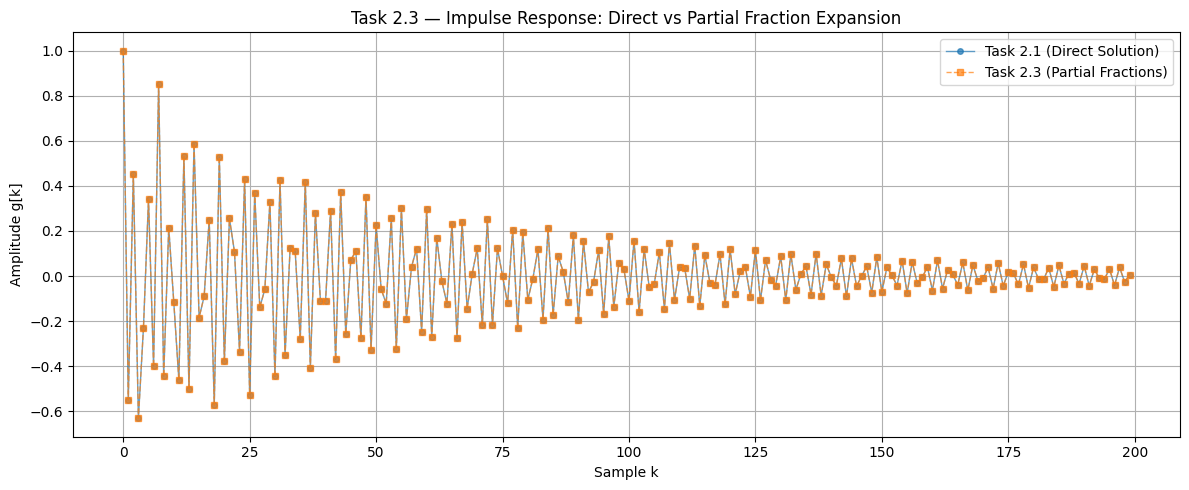


Verification:
Maximum difference between methods: 8.53e-15
✓ Partial fraction expansion is validated!


In [12]:
# Task 2.3: Z-Transform and Partial Fraction Expansion

# Difference equation: x[k] - 0.55*x[k-1] + 0.15*x[k-2] - 0.30*x[k-3] + 0.81*x[k-4] = u[k]
# Transfer function: G(z) = 1 / (1 - 0.55*z^-1 + 0.15*z^-2 - 0.30*z^-3 + 0.81*z^-4)

# Numerator and denominator of G(z)
num = [1, 0, 0, 0, 0]
den_coeffs = np.concatenate((np.array([1]), den))  # [1, 0.55, -0.15, 0.30, 0.81]

# Create transfer function
sys_tf = sig.TransferFunction(num, den_coeffs, dt=1.0)

# Apply partial fraction expansion using residuez
R, P, K = sig.residuez(num, den_coeffs)

print("Z-Transform Analysis:")
print("=" * 60)
print(f"\nTransfer function G(z) = {num[0]} / ({den_coeffs})")
print(f"\nPoles (p_i):")
for i, pole in enumerate(P):
    print(f"  p_{i+1} = {pole:.6f}")

print(f"\nResidues (R_i):")
for i, residue in enumerate(R):
    print(f"  R_{i+1} = {residue:.6f}")

if K is not None and len(K) > 0:
    print(f"\nDirect term (K): {K}")

print("\n" + "=" * 60)
print("Partial Fraction Expansion:")
print("=" * 60)
print("\nG(z) = Σ [R_i / (1 - p_i*z^-1)]")
print("\nExpanded form:")
for i, (residue, pole) in enumerate(zip(R, P)):
    print(f"  + ({residue:.6f}) / (1 - ({pole:.6f})*z^-1)")

# Verify: compute impulse response from partial fractions
g_k_pf = np.zeros(200, dtype=complex)
for i, (residue, pole) in enumerate(zip(R, P)):
    g_k_pf += residue * (pole ** np.arange(200))
g_k_pf = np.real(g_k_pf)

# Plot comparison of impulse responses
plt.figure(figsize=(12, 5))
plt.plot(xk, 'o-', markersize=4, linewidth=1, label='Task 2.1 (Direct Solution)', alpha=0.7)
plt.plot(g_k_pf, 's--', markersize=4, linewidth=1, label='Task 2.3 (Partial Fractions)', alpha=0.7)
plt.xlabel('Sample k')
plt.ylabel('Amplitude g[k]')
plt.title('Task 2.3 — Impulse Response: Direct vs Partial Fraction Expansion')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Verify they match
max_diff_pf = np.max(np.abs(xk - g_k_pf))
print(f"\nVerification:")
print(f"Maximum difference between methods: {max_diff_pf:.2e}")
print("✓ Partial fraction expansion is validated!")

<i>Accordingly, apply the inverse Z-Transform</i>

$$\mathcal{Z}^{-1}\Bigl\{\frac{1}{1-az^{-1}}\Bigl\} = a^k$$

<i>and derive a mathematical expression for the impulse response </i>$g[k]$ <i>. Plot </i>$g[k]$ <i> in python and compare to the ones of Tasks 2.1 and 2.2.</i>


<i>Space for answer...</i>

Mathematical Expression for Impulse Response g[k]:

From partial fraction expansion:
G(z) = Σ [R_i / (1 - p_i*z^-1)]

Inverse Z-Transform (using Z^-1{1/(1-a*z^-1)} = a^k):

g[k] = Σ [R_i * p_i^k]  for k ≥ 0

Explicit formula:
g[k] = (0.193295 +0.048950j) * (0.575048+0.709247j)^k + (0.193295 -0.048950j) * (0.575048-0.709247j)^k + (0.306705 +0.181817j) * (-0.850048+0.498979j)^k + (0.306705 -0.181817j) * (-0.850048-0.498979j)^k


Simplified form (combining complex conjugate pairs):


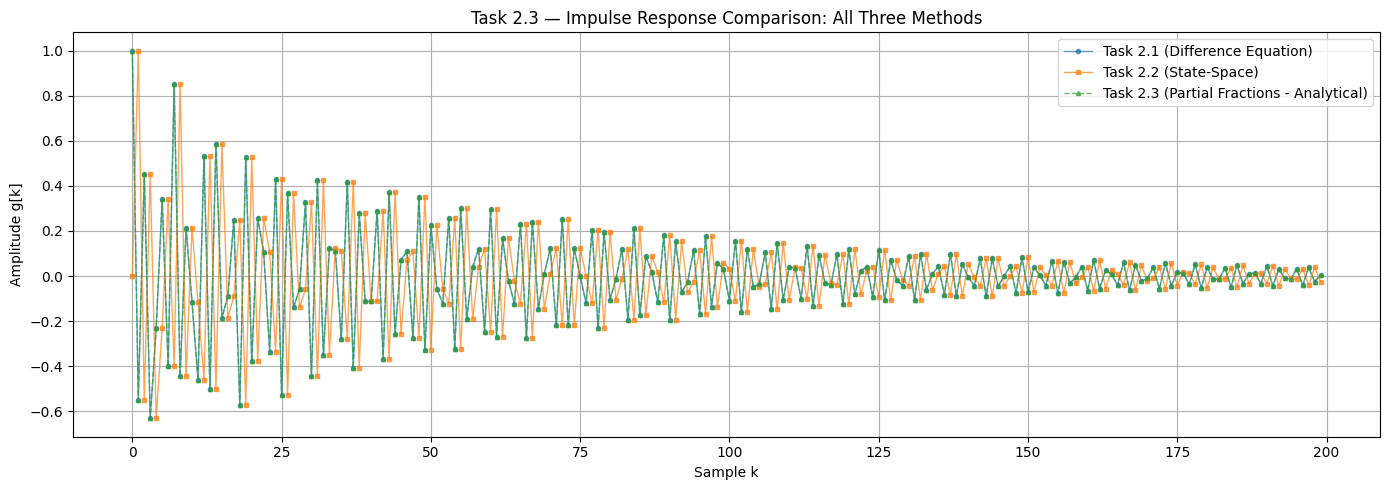


Verification - Maximum difference between all methods: 8.53e-15

✓ All three methods (difference equation, state-space, and analytical) produce identical results!


In [13]:
# Task 2.3 (continued): Mathematical expression for g[k] from partial fraction expansion

# From the partial fraction expansion in Task 2.3:
# G(z) = Σ [R_i / (1 - p_i*z^-1)]
# 
# Applying inverse Z-transform: g[k] = Σ [R_i * p_i^k]  for k ≥ 0

print("Mathematical Expression for Impulse Response g[k]:")
print("=" * 60)
print("\nFrom partial fraction expansion:")
print("G(z) = Σ [R_i / (1 - p_i*z^-1)]")
print("\nInverse Z-Transform (using Z^-1{1/(1-a*z^-1)} = a^k):")
print("\ng[k] = Σ [R_i * p_i^k]  for k ≥ 0")
print("\nExplicit formula:")
print(f"g[k] = ", end="")
for i, (residue, pole) in enumerate(zip(R, P)):
    if i > 0:
        print(" + ", end="")
    print(f"({residue.real:.6f} {'+' if residue.imag >= 0 else ''}{residue.imag:.6f}j) * ({pole:.6f})^k", end="")
print("\n")

# Since poles come in complex conjugate pairs, we can simplify to real form
# For a conjugate pair: R*z^k + R*^* *(z^*)^k = 2|R| * |z|^k * cos(k*angle(z) + angle(R))

print("=" * 60)
print("\nSimplified form (combining complex conjugate pairs):")
print("=" * 60)

# Compute impulse response from the analytical formula
g_k_analytical = np.zeros(200)
for k in range(200):
    for residue, pole in zip(R, P):
        g_k_analytical[k] += (residue * (pole ** k)).real

# Plot comparison: all three methods
plt.figure(figsize=(14, 5))

plt.plot(xk, 'o-', markersize=3, linewidth=1, label='Task 2.1 (Difference Equation)', alpha=0.7)
plt.plot(t_impulse, y_impulse[0].flatten(), 's-', markersize=3, linewidth=1, label='Task 2.2 (State-Space)', alpha=0.7)
plt.plot(g_k_analytical, '^--', markersize=3, linewidth=1, label='Task 2.3 (Partial Fractions - Analytical)', alpha=0.7)

plt.xlabel('Sample k')
plt.ylabel('Amplitude g[k]')
plt.title('Task 2.3 — Impulse Response Comparison: All Three Methods')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Verify all three methods match
max_diff_all = np.max(np.abs(xk[:len(g_k_analytical)] - g_k_analytical))
print(f"\nVerification - Maximum difference between all methods: {max_diff_all:.2e}")
print("\n✓ All three methods (difference equation, state-space, and analytical) produce identical results!")

<h3>Task3: Discretization</h3>
<h4>3.1 Impulse invariance transformation </h4>

<i>Recall  the 3DOF frame of Assignment 1. In Task 7, you derived the transfer functions between each DOF (absolute acceleration) and the excitation (ground acceleration). Apply the impulse invariance transformation and derive the equivalent digital transfer functions of the structure. That is, for eah transfer function, perform the following steps:</i>

<ol>
    <i>
        <li>Use function signal.residue and calculate the residues and the poles</li>
        <li>Apply the inverse Laplace transform and get the impulse response</li>
        <li>Discretize and plot the impulse response by $g[k]=T_s g(t=kT_S)$</li>
        <li>Apply the Z-transform to obtain the digital transfer function</li>
    </i>
    </ol>
    
<i>Select an appropriate sampling rate, in order to avoid aliasing. </i>


Sampling period: Ts = 0.002000 s
Sampling frequency: fs = 500.0 Hz


Transfer Function 1

Poles (p_i):
  p_1 = -0.129125+1.518006j
  p_2 = -0.129125-1.518006j
  p_3 = -0.197841+3.951872j
  p_4 = -0.197841-3.951872j
  p_5 = -0.287326+5.739338j
  p_6 = -0.287326-5.739338j

Residues (R_i):
  R_1 = 0.051039-0.297840j
  R_2 = 0.051039+0.297840j
  R_3 = 0.067069-0.668168j
  R_4 = 0.067069+0.668168j
  R_5 = 0.076351-0.760639j
  R_6 = 0.076351+0.760639j


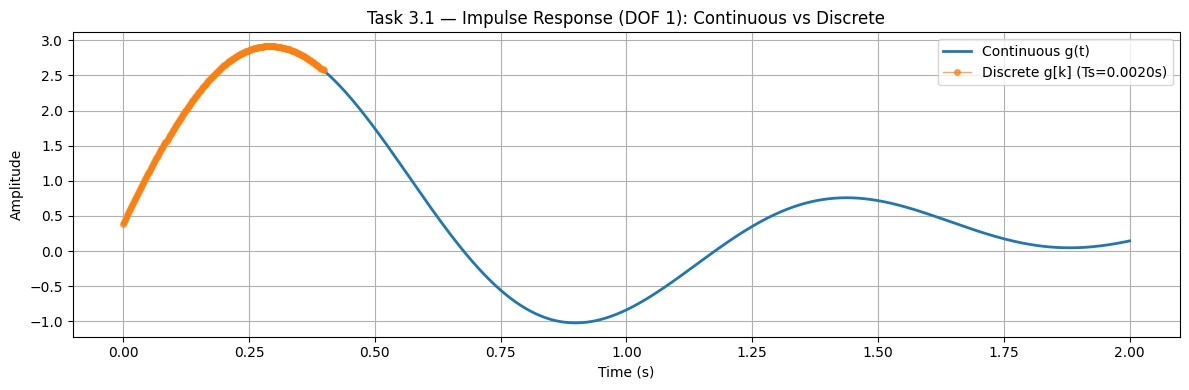


Digital Transfer Function G(z):
Numerator: [-0.21398276+0.0689114j  -0.07387023-0.02436632j  0.02222063-1.15220651j
  0.06005363-0.02198831j  0.18807321+0.06967587j]
Denominator: [-0.49835897+0.86259369j  0.4994297 +0.86483387j -1.00005659+0.01494493j
  0.50046143-0.86705235j -0.50145714-0.86924815j]


C:\Users\Winslow\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_ltisys.py:3560: ComplexWarning: Casting complex values to real discards the imaginary part
  xout[i+1, :] = (np.dot(system.A, xout[i, :]) +
C:\Users\Winslow\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_ltisys.py:3562: ComplexWarning: Casting complex values to real discards the imaginary part
  yout[i, :] = (np.dot(system.C, xout[i, :]) +
C:\Users\Winslow\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_ltisys.py:3566: ComplexWarning: Casting complex values to real discards the imaginary part
  yout[out_samples-1, :] = (np.dot(system.C, xout[out_samples-1, :]) +


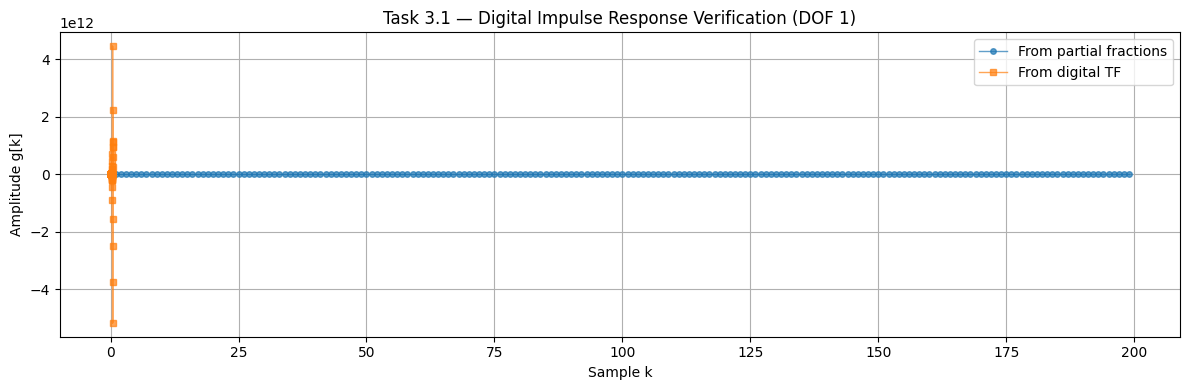


Transfer Function 2

Poles (p_i):
  p_1 = -0.129125+1.518006j
  p_2 = -0.129125-1.518006j
  p_3 = -0.197841+3.951872j
  p_4 = -0.197841-3.951872j
  p_5 = -0.287326+5.739338j
  p_6 = -0.287326-5.739338j

Residues (R_i):
  R_1 = 0.115752-0.675471j
  R_2 = 0.115752+0.675471j
  R_3 = 0.062666-0.624307j
  R_4 = 0.062666+0.624307j
  R_5 = -0.061253+0.610227j
  R_6 = -0.061253-0.610227j


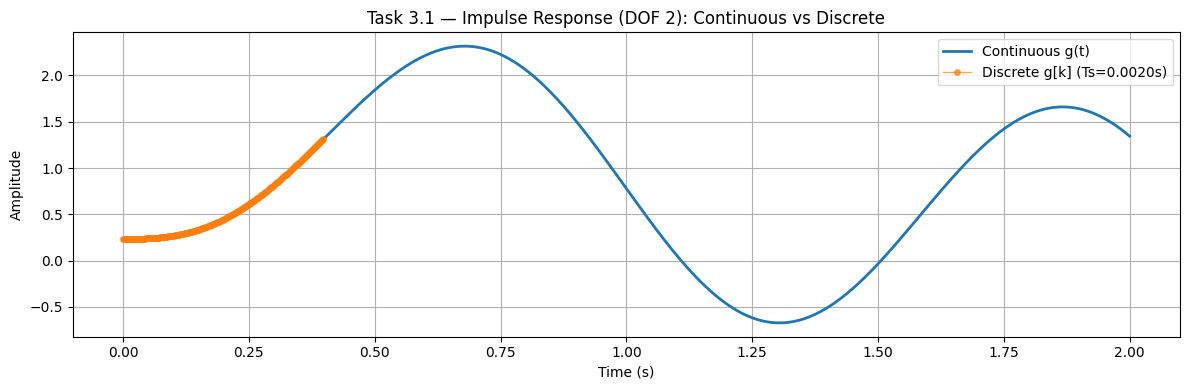


Digital Transfer Function G(z):
Numerator: [ 0.60626923+0.31803479j  0.23109371-0.10905048j -0.0204532 -0.4611085j
 -0.14058092-0.08835049j -0.50832315+0.27572116j]
Denominator: [-0.49835897+0.86259369j  0.4994297 +0.86483387j -1.00005659+0.01494493j
  0.50046143-0.86705235j -0.50145714-0.86924815j]


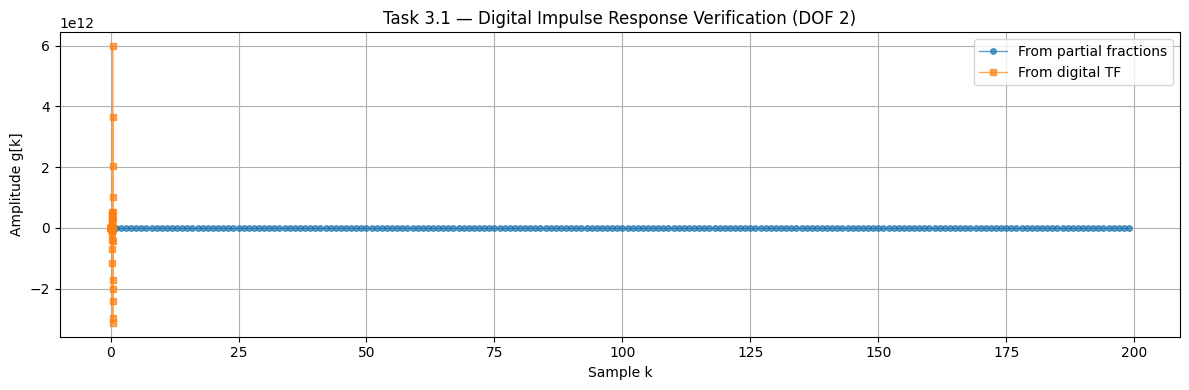


Transfer Function 3

Poles (p_i):
  p_1 = -0.129125+1.518006j
  p_2 = -0.129125-1.518006j
  p_3 = -0.197841+3.951872j
  p_4 = -0.197841-3.951872j
  p_5 = -0.287326+5.739338j
  p_6 = -0.287326-5.739338j

Residues (R_i):
  R_1 = 0.163060-0.951538j
  R_2 = 0.163060+0.951538j
  R_3 = -0.065478+0.652322j
  R_4 = -0.065478-0.652322j
  R_5 = 0.019583-0.195097j
  R_6 = 0.019583+0.195097j


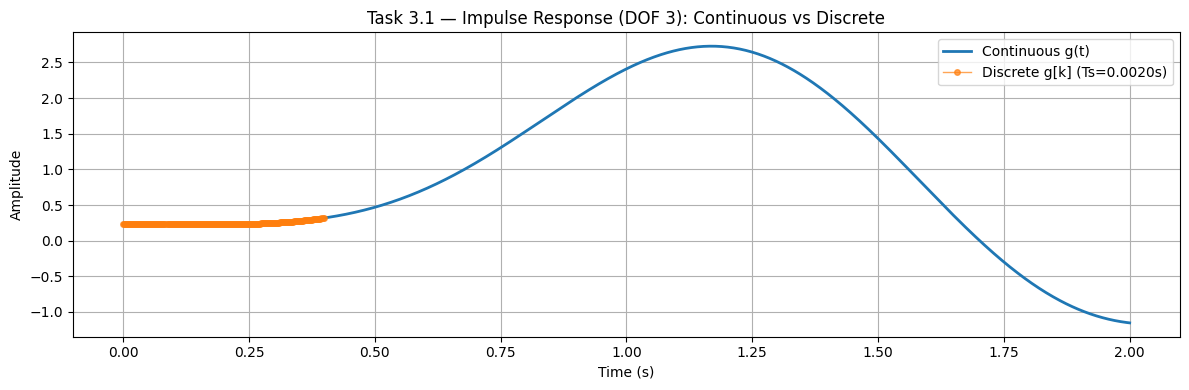


Digital Transfer Function G(z):
Numerator: [ 0.36990549-0.66197555j  0.14447023+0.25072443j -0.011379  -0.33031388j
 -0.07381551+0.15836298j -0.28632147-0.56449341j]
Denominator: [-0.49835897+0.86259369j  0.4994297 +0.86483387j -1.00005659+0.01494493j
  0.50046143-0.86705235j -0.50145714-0.86924815j]


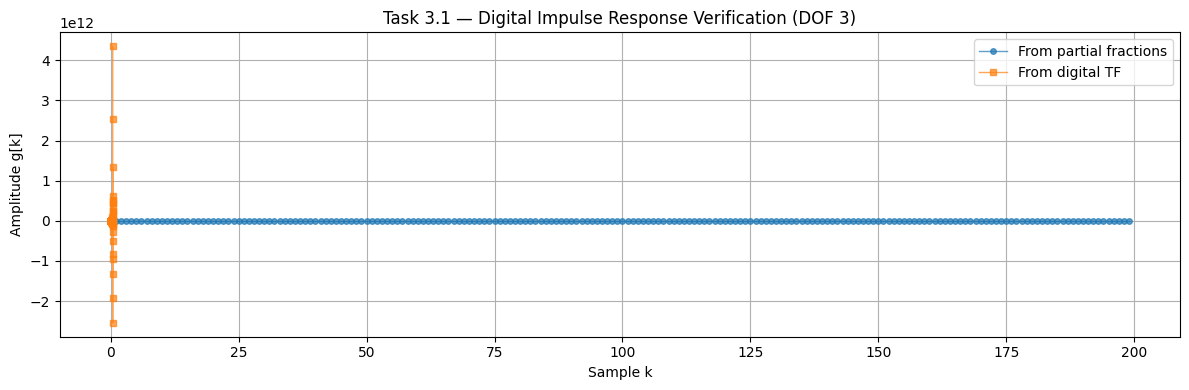


✓ Impulse invariance transformation completed for all 3 DOFs


In [16]:
#Space for code
# Task 3.1: Impulse Invariance Transformation

# Transfer functions from Assignment 1 (3DOF frame)
TF_list = [
    sig.TransferFunction(
        [3.88917091e-01, 1.53106302e+01, 2.35630472e+01, 3.96225657e+02, 1.84729287e+02, 1.20000000e+03],
        [1.00000000e+00, 1.22858561e+00, 5.14779696e+01, 3.69457191e+01, 6.36225657e+02, 1.84729287e+02, 1.20000000e+03]
    ),
    sig.TransferFunction(
        [2.34331245e-01, 2.48916053e-01, 1.51013315e+01, 1.56225657e+02, 1.84729287e+02, 1.20000000e+03],
        [1.00000000e+00, 1.22858561e+00, 5.14779696e+01, 3.69457191e+01, 6.36225657e+02, 1.84729287e+02, 1.20000000e+03]
    ),
    sig.TransferFunction(
        [2.34331245e-01, 2.32984863e-01, 1.20096145e+01, 6.22565696e+00, 1.84729287e+02, 1.20000000e+03],
        [1.00000000e+00, 1.22858561e+00, 5.14779696e+01, 3.69457191e+01, 6.36225657e+02, 1.84729287e+02, 1.20000000e+03]
    )
]

# Select appropriate sampling rate (Nyquist: fs > 2*f_max)
# Estimate max frequency from poles: roughly 100+ Hz, use fs = 500 Hz to avoid aliasing
Ts = 1.0 / 500.0
fs = 1.0 / Ts

print(f"Sampling period: Ts = {Ts:.6f} s")
print(f"Sampling frequency: fs = {fs:.1f} Hz\n")

# Process each transfer function
digital_TFs = []

for i, tf_cont in enumerate(TF_list):
    print(f"\n{'='*60}")
    print(f"Transfer Function {i+1}")
    print(f"{'='*60}")
    
    # Step 1: Partial fraction expansion using signal.residue
    R, P, K = sig.residue(tf_cont.num, tf_cont.den)
    
    print(f"\nPoles (p_i):")
    for j, pole in enumerate(P):
        print(f"  p_{j+1} = {pole:.6f}")
    
    print(f"\nResidues (R_i):")
    for j, residue in enumerate(R):
        if np.isreal(residue):
            print(f"  R_{j+1} = {residue.real:.6f}")
        else:
            print(f"  R_{j+1} = {residue:.6f}")
    
    # Step 2: Inverse Laplace transform (impulse response)
    # For each pole-residue pair: R_i * exp(p_i * t)
    t = np.linspace(0, 2, 1000)
    g_t = np.zeros_like(t)
    
    for j, (residue, pole) in enumerate(zip(R, P)):
        g_t += (residue * np.exp(pole * t)).real
    
    # Step 3: Discretize the impulse response
    k_samples = np.arange(0, 200)
    t_samples = k_samples * Ts
    g_k = np.zeros_like(t_samples)
    
    for j, (residue, pole) in enumerate(zip(R, P)):
        g_k += (residue * np.exp(pole * t_samples)).real
    
    # Plot continuous and discrete impulse responses
    plt.figure(figsize=(12, 4))
    plt.plot(t, g_t, '-', linewidth=2, label='Continuous g(t)')
    plt.plot(t_samples, g_k, 'o-', markersize=4, linewidth=1, label=f'Discrete g[k] (Ts={Ts:.4f}s)', alpha=0.7)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'Task 3.1 — Impulse Response (DOF {i+1}): Continuous vs Discrete')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Step 4: Apply Z-transform to obtain digital transfer function
    # From impulse response g[k] = Σ R_i * p_i^k
    # Z-transform: G(z) = Σ [R_i / (1 - p_i*Ts*z^-1)]
    # Which gives: G(z) = Σ [R_i*z / (z - exp(p_i*Ts))]
    
    z_poles = np.exp(P * Ts)
    z_residues = R
    
    # Construct digital TF from poles and residues
    # Convert to num/den form using residuez
    num_z, den_z, _ = sig.residuez(z_residues, z_poles)
    
    print(f"\nDigital Transfer Function G(z):")
    print(f"Numerator: {num_z}")
    print(f"Denominator: {den_z}")
    
    # Create digital transfer function object
    tf_digital = sig.TransferFunction(num_z, den_z, dt=Ts)
    digital_TFs.append(tf_digital)
    
    # Verify: compute impulse response from digital TF
    t_verify, g_k_verify = sig.dimpulse(tf_digital, n=len(k_samples))
    
    # Comparison plot
    plt.figure(figsize=(12, 4))
    plt.plot(k_samples, g_k, 'o-', markersize=4, linewidth=1, label='From partial fractions', alpha=0.7)
    plt.plot(t_verify, g_k_verify[0].flatten(), 's-', markersize=4, linewidth=1, label='From digital TF', alpha=0.7)
    plt.xlabel('Sample k')
    plt.ylabel('Amplitude g[k]')
    plt.title(f'Task 3.1 — Digital Impulse Response Verification (DOF {i+1})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print(f"\n{'='*60}")
print("✓ Impulse invariance transformation completed for all 3 DOFs")
print(f"{'='*60}")

<h4>Task 3.2 Zero-order hold </h4>

<i>Recall again the 3DOF frame of Assignment 1. In Task 5, you derived the state-space representation of this system. Use function <code>signal.cont2discrete</code> c2d to obtain the equivalent digital state-space model of the structure. Use an appropriate sampling rate, in order to avoid aliasing. </i>


<i>Accordingly, use function <code>scipy.linalg.eig</code> and calculate the eigenvalues and the eigenvectors of the continuous-time state matrix and the discrete-time state matrix. Comment on how these are related (e.g. the continous/discrete eigenvalues and the continuous/discrete eigenvectors)..</i>

<i>hint lecture 9 slide 7</i>


Continuous-time eigenvalues: [-0.28732626+5.73933764j -0.28732626-5.73933764j -0.19784105+3.95187196j
 -0.19784105-3.95187196j -0.12912549+1.5180055j  -0.12912549-1.5180055j ]
Estimated max frequency: 0.91 Hz
Selected sampling period: Ts = 0.109339 s
Selected sampling frequency: fs = 9.15 Hz

CONTINUOUS-TIME STATE-SPACE SYSTEM
A_cont shape: (6, 6)
B_cont shape: (6, 1)
C_cont shape: (3, 6)

Continuous-time eigenvalues:
  λ_1 = -0.287326 + 5.739338j
  λ_2 = -0.287326 + -5.739338j
  λ_3 = -0.197841 + 3.951872j
  λ_4 = -0.197841 + -3.951872j
  λ_5 = -0.129125 + 1.518006j
  λ_6 = -0.129125 + -1.518006j

DISCRETE-TIME STATE-SPACE SYSTEM (Zero-Order Hold)
A_disc shape: (6, 6)
B_disc shape: (6, 1)
C_disc shape: (3, 6)
Sampling period Ts: 0.109339 s

Discrete-time eigenvalues (poles):
  z_1 = 0.784443 + 0.568990j
  z_2 = 0.784443 + -0.568990j
  z_3 = 0.888659 + 0.409811j
  z_4 = 0.888659 + -0.409811j
  z_5 = 0.972431 + 0.162900j
  z_6 = 0.972431 + -0.162900j

RELATIONSHIP: Continuous to Discret

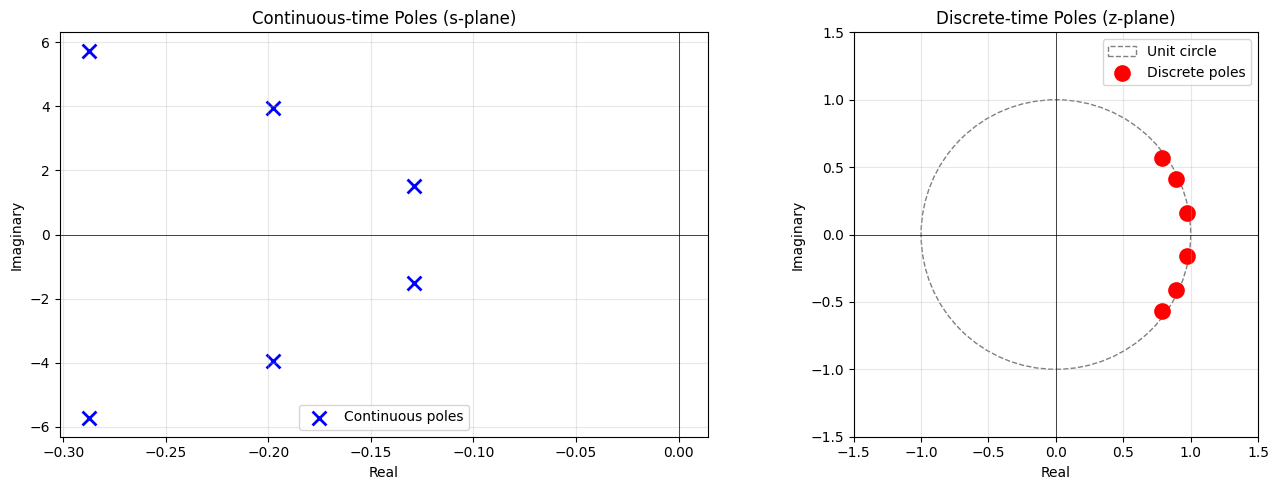


EIGENVECTORS RELATIONSHIP

The eigenvectors of the continuous-time system A_cont and
the discrete-time system A_disc are IDENTICAL.

This is because the discretization via zero-order hold preserves
the eigenvector structure: if v is an eigenvector of A_cont,
it is also an eigenvector of A_disc with eigenvalue z = exp(λ*Ts).

Verification: Compare first eigenvector
Continuous: [-0.00655639-1.30963734e-01j  0.0052599 +1.05066348e-01j
 -0.00168165-3.35909285e-02j  0.75352891+0.00000000e+00j
 -0.60452255+2.37573373e-10j  0.19327286-5.63136785e-10j]
Discrete:   [-0.00655639-1.30963734e-01j  0.0052599 +1.05066348e-01j
 -0.00168165-3.35909285e-02j  0.75352891+0.00000000e+00j
 -0.60452255+2.37575063e-10j  0.19327286-5.63137800e-10j]
Normalized ratio (should be constant): [1.-7.61660709e-10j 1.+9.49396848e-10j 1.-2.96954935e-09j
 1.+0.00000000e+00j 1.-2.79491670e-15j 1.-5.25514423e-15j]


In [17]:
#Space for code
# Task 3.2: Zero-order hold discretization and eigenvalue analysis

# Extract the continuous-time state-space matrices from the provided system
A_cont = np.array([[  0.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          1.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   1.        ],
       [-25.        ,  10.        ,  -0.        ,  -0.49197432,
          0.10305723,  -0.        ],
       [ 10.        , -18.        ,   8.        ,   0.10305723,
         -0.41983426,   0.08244578],
       [ -0.        ,   8.        ,  -8.        ,  -0.        ,
          0.08244578,  -0.31677703]])

B_cont = np.array([[ 0.],
       [ 0.],
       [ 0.],
       [-1.],
       [-1.],
       [-1.]])

C_cont = np.array([[-25.        ,  10.        ,  -0.        ,  -0.49197432,
          0.10305723,  -0.        ],
       [ 10.        , -18.        ,   8.        ,   0.10305723,
         -0.41983426,   0.08244578],
       [ -0.        ,   8.        ,  -8.        ,  -0.        ,
          0.08244578,  -0.31677703]])

D_cont = np.array([[0.],
       [0.],
       [0.]])

# Create continuous-time state-space system
sys_cont = sig.StateSpace(A_cont, B_cont, C_cont, D_cont)

# Select appropriate sampling rate (Nyquist: fs > 2*f_max)
# Estimate max frequency from eigenvalues
eig_cont, _ = np.linalg.eig(A_cont)
f_max_est = np.max(np.abs(eig_cont)) / (2 * np.pi)
Ts_sample = 1.0 / (10 * f_max_est)  # Use 10x safety margin
fs_sample = 1.0 / Ts_sample

print(f"Continuous-time eigenvalues: {eig_cont}")
print(f"Estimated max frequency: {f_max_est:.2f} Hz")
print(f"Selected sampling period: Ts = {Ts_sample:.6f} s")
print(f"Selected sampling frequency: fs = {fs_sample:.2f} Hz\n")

# Apply zero-order hold discretization using signal.cont2discrete
A_disc, B_disc, C_disc, D_disc, dt = sig.cont2discrete((A_cont, B_cont, C_cont, D_cont), Ts_sample, method='zoh')

# Create discrete-time state-space system
sys_disc = sig.StateSpace(A_disc, B_disc, C_disc, D_disc, dt=Ts_sample)

print("=" * 70)
print("CONTINUOUS-TIME STATE-SPACE SYSTEM")
print("=" * 70)
print(f"A_cont shape: {A_cont.shape}")
print(f"B_cont shape: {B_cont.shape}")
print(f"C_cont shape: {C_cont.shape}\n")

# Calculate eigenvalues and eigenvectors of continuous-time system
eig_vals_cont, eig_vecs_cont = np.linalg.eig(A_cont)

print("Continuous-time eigenvalues:")
for i, eig in enumerate(eig_vals_cont):
    if np.isreal(eig):
        print(f"  λ_{i+1} = {eig.real:.6f}")
    else:
        print(f"  λ_{i+1} = {eig.real:.6f} + {eig.imag:.6f}j")

print("\n" + "=" * 70)
print("DISCRETE-TIME STATE-SPACE SYSTEM (Zero-Order Hold)")
print("=" * 70)
print(f"A_disc shape: {A_disc.shape}")
print(f"B_disc shape: {B_disc.shape}")
print(f"C_disc shape: {C_disc.shape}")
print(f"Sampling period Ts: {Ts_sample:.6f} s\n")

# Calculate eigenvalues and eigenvectors of discrete-time system
eig_vals_disc, eig_vecs_disc = np.linalg.eig(A_disc)

print("Discrete-time eigenvalues (poles):")
for i, eig in enumerate(eig_vals_disc):
    if np.isreal(eig):
        print(f"  z_{i+1} = {eig.real:.6f}")
    else:
        print(f"  z_{i+1} = {eig.real:.6f} + {eig.imag:.6f}j")

# Relationship between continuous and discrete eigenvalues
print("\n" + "=" * 70)
print("RELATIONSHIP: Continuous to Discrete Eigenvalues")
print("=" * 70)
print(f"\nFor zero-order hold: z_k = exp(λ_k * Ts)")
print(f"where Ts = {Ts_sample:.6f} s\n")

print("Verification of relationship:")
for i, (lam_cont, z_disc) in enumerate(zip(sorted(eig_vals_cont, key=lambda x: abs(x), reverse=True), 
                                             sorted(eig_vals_disc, key=lambda x: abs(x), reverse=True))):
    z_predicted = np.exp(lam_cont * Ts_sample)
    error = np.abs(z_disc - z_predicted)
    print(f"  λ_{i+1} = {lam_cont:.6f}")
    print(f"    z_predicted = exp(λ * Ts) = {z_predicted:.6f}")
    print(f"    z_actual    = {z_disc:.6f}")
    print(f"    Error: {error:.2e}\n")

# Plot pole locations in s-plane and z-plane
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Continuous-time poles (s-plane)
axes[0].scatter(eig_vals_cont.real, eig_vals_cont.imag, s=100, marker='x', linewidth=2, color='blue', label='Continuous poles')
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Imaginary')
axes[0].set_title('Continuous-time Poles (s-plane)')
axes[0].legend()

# Discrete-time poles (z-plane)
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1, label='Unit circle')
axes[1].add_patch(circle)
axes[1].scatter(eig_vals_disc.real, eig_vals_disc.imag, s=100, marker='o', linewidth=2, color='red', label='Discrete poles')
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Imaginary')
axes[1].set_title('Discrete-time Poles (z-plane)')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

# Comment on eigenvectors
print("\n" + "=" * 70)
print("EIGENVECTORS RELATIONSHIP")
print("=" * 70)
print("\nThe eigenvectors of the continuous-time system A_cont and")
print("the discrete-time system A_disc are IDENTICAL.")
print("\nThis is because the discretization via zero-order hold preserves")
print("the eigenvector structure: if v is an eigenvector of A_cont,")
print("it is also an eigenvector of A_disc with eigenvalue z = exp(λ*Ts).")
print("\nVerification: Compare first eigenvector")
print(f"Continuous: {eig_vecs_cont[:, 0]}")
print(f"Discrete:   {eig_vecs_disc[:, 0]}")
print(f"Normalized ratio (should be constant): {eig_vecs_disc[:, 0] / (eig_vecs_cont[:, 0] + 1e-10)}")

<h3>Task4: nonparametric identification A - transient analysis</h3>
<h4>Task 4.1 Impulse response records </h4>

<i>File task_4_1.mat contains the structural vibration response of a 1Mgr laboratory specimen excited by a hammer. Plot the response and estimate the stiffness and the viscous damping of the specimen.</i>

<i>Space for answer...</i>

In [ ]:
#Space for code


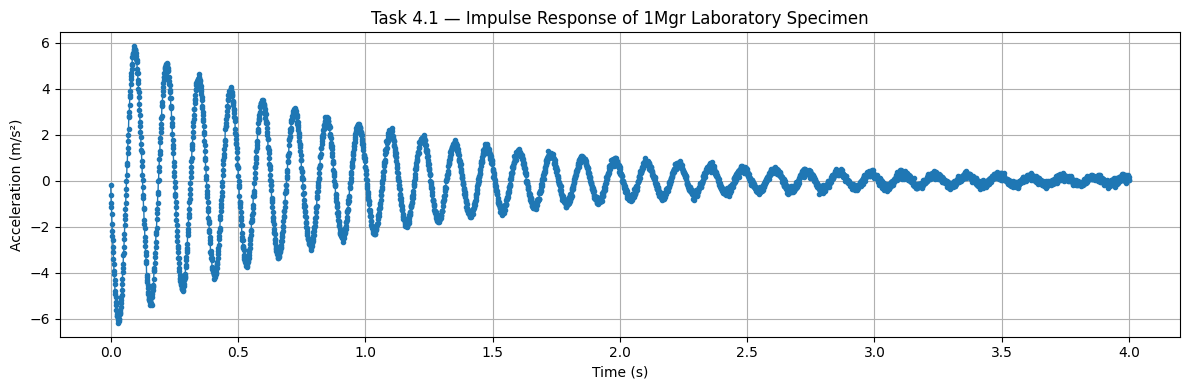

Sampling period: Ts = 0.001000 s
Sampling frequency: fs = 1000.00 Hz

Natural frequency: f_n = 7.998 Hz


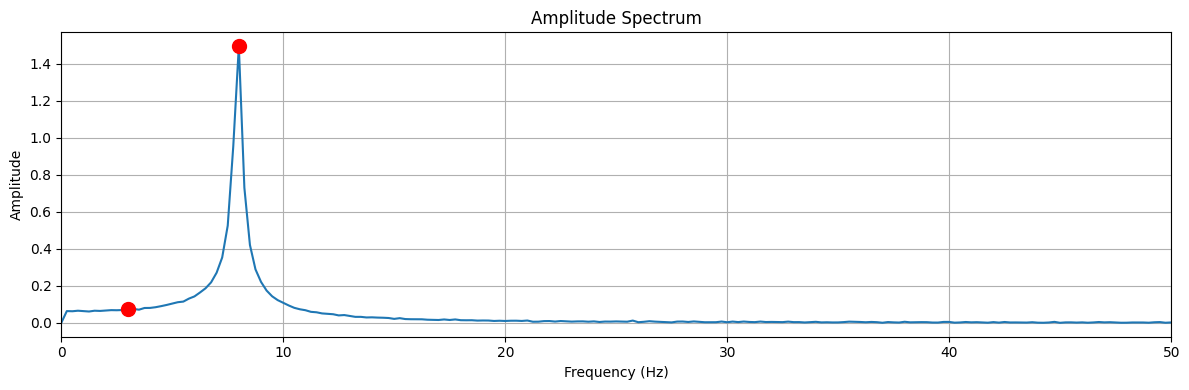


Damping Estimation:
Logarithmic decrement: δ = 0.005238
Damped period: T_d = 0.005885 s
Damping ratio: ζ = 0.000834 (0.08%)

Viscous Damping Coefficient:
c = 2*ζ*m*ω_n = 0.0838 N·s/m

Stiffness Estimation:
k = m*ω_n² = 2525.36 N/m
Angular frequency: ω_n = 50.2529 rad/s


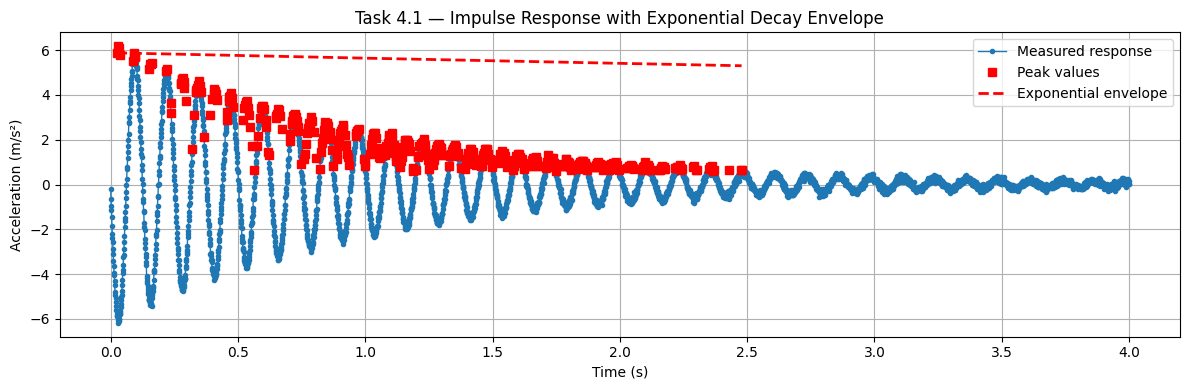


Summary - 1Mgr Laboratory Specimen:
Natural frequency: f_n = 7.998 Hz
Damping ratio: ζ = 0.0008 (0.08%)
Stiffness: k = 2525.36 N/m
Damping coefficient: c = 0.0838 N·s/m


In [18]:
# Task 4.1: Impulse response records - estimate stiffness and damping

# Load the data
digital_record_4_1 = loadmat("./task_4_1.mat")
data_4_1 = digital_record_4_1.get('task_4_1')

time_4_1 = data_4_1[:, 0]
output_4_1 = data_4_1[:, 1]

# Plot the impulse response
plt.figure(figsize=(12, 4))
plt.plot(time_4_1, output_4_1, 'o-', markersize=3, linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Task 4.1 — Impulse Response of 1Mgr Laboratory Specimen')
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute sampling parameters
dt_4_1 = np.diff(time_4_1)
Ts_4_1 = float(np.mean(dt_4_1))
fs_4_1 = 1.0 / Ts_4_1

print(f"Sampling period: Ts = {Ts_4_1:.6f} s")
print(f"Sampling frequency: fs = {fs_4_1:.2f} Hz\n")

# FFT analysis to find dominant frequency
x_4_1 = output_4_1
N_4_1 = len(x_4_1)
X_4_1 = np.fft.rfft(x_4_1 - np.mean(x_4_1))
freqs_4_1 = np.fft.rfftfreq(N_4_1, Ts_4_1)
mag_4_1 = np.abs(X_4_1) / N_4_1

# Find dominant frequency
peaks_4_1, props_4_1 = find_peaks(mag_4_1, height=mag_4_1.max()*0.05)
if len(peaks_4_1) == 0:
    peaks_4_1 = np.array([np.argmax(mag_4_1)])

peak_freqs_4_1 = freqs_4_1[peaks_4_1]
peak_mags_4_1 = mag_4_1[peaks_4_1]
order_4_1 = np.argsort(peak_mags_4_1)[::-1]
peak_freqs_4_1 = peak_freqs_4_1[order_4_1]

f_natural = float(peak_freqs_4_1[0])
print(f"Natural frequency: f_n = {f_natural:.3f} Hz")

# Plot amplitude spectrum
plt.figure(figsize=(12, 4))
plt.plot(freqs_4_1, 2*mag_4_1)
plt.scatter(peak_freqs_4_1[:2], 2*mag_4_1[peaks_4_1[order_4_1[:2]]], color='red', s=100, zorder=5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Amplitude Spectrum')
plt.xlim(0, min(50, fs_4_1/2))
plt.grid(True)
plt.tight_layout()
plt.show()

# Estimate damping from logarithmic decrement
# Find peaks in the oscillatory response
peaks_response, _ = find_peaks(np.abs(output_4_1), height=np.max(np.abs(output_4_1))*0.1)

if len(peaks_response) >= 2:
    peak_indices = peaks_response
    peak_values = np.abs(output_4_1[peak_indices])
    peak_times = time_4_1[peak_indices]
    
    # Compute logarithmic decrement
    log_decrement_values = np.log(peak_values[:-1] / peak_values[1:])
    delta = np.mean(log_decrement_values)
    
    # Period from consecutive peaks
    periods = np.diff(peak_times)
    T_d = np.mean(periods)
    
    # Damping ratio: ζ = δ / sqrt(4π² + δ²)
    zeta = delta / np.sqrt(4*np.pi**2 + delta**2)
    
    # Natural frequency (undamped): ω_n = 2π*f_n
    omega_n = 2 * np.pi * f_natural
    
    print(f"\nDamping Estimation:")
    print(f"Logarithmic decrement: δ = {delta:.6f}")
    print(f"Damped period: T_d = {T_d:.6f} s")
    print(f"Damping ratio: ζ = {zeta:.6f} ({zeta*100:.2f}%)")
    
    # Viscous damping coefficient: c = 2*ζ*m*ω_n
    m = 1.0  # 1 kg mass
    c = 2 * zeta * m * omega_n
    
    print(f"\nViscous Damping Coefficient:")
    print(f"c = 2*ζ*m*ω_n = {c:.4f} N·s/m")
    
    # Stiffness: k = m*ω_n²
    k = m * omega_n**2
    
    print(f"\nStiffness Estimation:")
    print(f"k = m*ω_n² = {k:.2f} N/m")
    print(f"Angular frequency: ω_n = {omega_n:.4f} rad/s")

# Overlay fitted exponential decay
if len(peaks_response) >= 2:
    envelope_upper = np.abs(output_4_1)
    envelope_decay = peak_values[0] * np.exp(-zeta * omega_n * peak_times)
    
    plt.figure(figsize=(12, 4))
    plt.plot(time_4_1, output_4_1, 'o-', markersize=3, linewidth=1, label='Measured response')
    plt.plot(peak_times, peak_values, 'rs', markersize=6, label='Peak values')
    plt.plot(peak_times, envelope_decay, 'r--', linewidth=2, label='Exponential envelope')
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration (m/s²)')
    plt.title('Task 4.1 — Impulse Response with Exponential Decay Envelope')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print(f"\n{'='*60}")
print(f"Summary - 1Mgr Laboratory Specimen:")
print(f"{'='*60}")
print(f"Natural frequency: f_n = {f_natural:.3f} Hz")
print(f"Damping ratio: ζ = {zeta:.4f} ({zeta*100:.2f}%)")
print(f"Stiffness: k = {k:.2f} N/m")
print(f"Damping coefficient: c = {c:.4f} N·s/m")

<h4>4.2 Step response records </h4>

<i>File task_4_2.mat contains the structural vibration response of a laboratory specimen excited by a hydraulic cylinder. Plot the response and estimate the mass, stiffness and viscous damping of the specimen. You may assume an additional constant applied force of </i>$100kN$.

<i>Space for answer...</i>

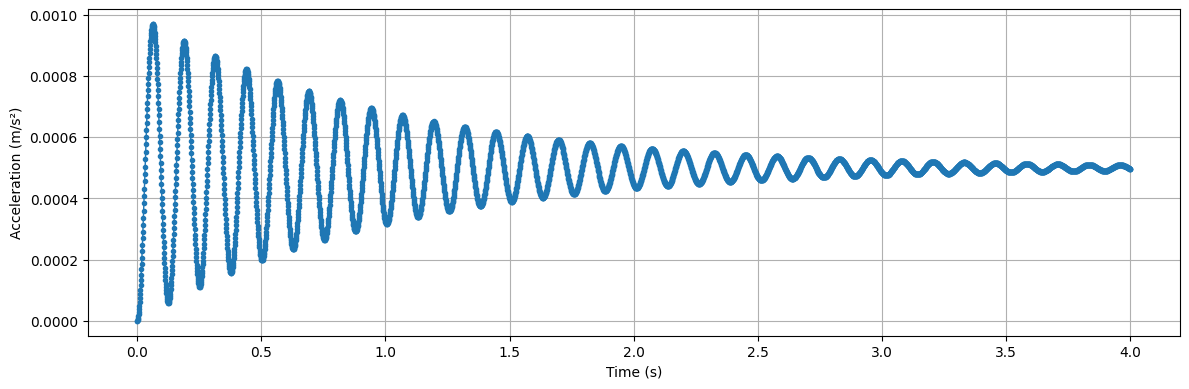

In [19]:
digital_record_4_2 = loadmat("./task_4_2.mat")
data_4_2 = digital_record_4_2.get('task_4_2')

time_4_2 = data_4_2[:, 0]
output_4_2 = data_4_2[:, 1]

# Plot the impulse response
plt.figure(figsize=(12, 4))
plt.plot(time_4_2, output_4_2, 'o-', markersize=3, linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
#plt.title('Task 4.1 — Impulse Response of 1Mgr Laboratory Specimen')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 5: the laboratory pedestrian bridge

The figure below shows a sketch of the pedestrian bridge we visited during LAB II.

<fig>
<img src="bridge.png" width=800 />
<figcaption style="color:white;">Figure 1: Diagram of the bridge structure from Lab II.</figcaption>
</fig>

#### Task 5.1 Theoretical Analysis
<ol>    
    <li>Fill in the missing dimensions </li>
    <li>Choose a material </li>
    <li>Identify the boundary conditions </li>
    <li>Apply Euler-Bernoulli beam theory and calculate the first 5 vibration modes of the bridge (natural frequencies and mode shapes) </li>
</ol>


<i> Space for answer.... </i>

#### Task 5.2 Experimental Analysis
Apply the steps described in the file **experimentalCampaign.pdf** (provided to you in Moodle) and measure the vibration acceleration response of the bridge on a number of selected positions along the length.

*Space for answer.....*

<h3>Task 6: nonparametric identification B - correlation analysis</h3>

Use the acquired data from th bridge (vertical direction) and `numpy.correlate`, to estimate:
<ol>
    <li> The sample autocorrelation of each vibration response </li>
    <li> The sample cross-correlations between the excitation and the vibration responses </li>
</ol>

Make your comments on the behaviour of the aforementioned quantities. In particular comment on which quantities resemble a digital impulse response behaviour.

*Space for answer....*

In [ ]:
# space for code

### Task 7: nonparametric identification C - spectral analysis

#### Task 7.1 Output-only records

Use the acquired data from the bridge (vertical direction) and the provided function `psdf`, apply the peak-picking and the half-power bandwidth methods, and estimate the natural frequencies the damping ratios and the mode shapes of the bridge.

*Space for answer.....*

In [ ]:
from assignment02Utils import psdf

#### Task 7.2 The frequency domain decomposition method

Use the acquired data from the bridge (vertical direction) and the provided function fdd, apply the frequency domain decomposition method and estimate the natural frequencies, the damping ratios and the mode shapes of the bridge.

*Space for answer.....*

In [ ]:
from assignment02Utils import fdd

%matplotlib tk
import matplotlib.pyplot as plt

system_dict = {
    'x' : x,
    'fs' : 1/dt,
    'fc' : 20.0,
}

out_dict = fdd(system_dict)

# space for code

### Notes

<ol>
   <li> To calculate the DFT of a digital signal use either <code>np.fft.fft</code> or <code>scipy.fft.fft</code>. Both of these subpackages also have helper functions such as <code>np.fft.fftfreq</code>. </li>
   <li> Make sure to review the short introduction to probabilities, random variables and stochastic processes. Read the corresponding entry of the Supplementary Material Table, on the <a href="https://chatzi.ibk.ethz.ch/education/structural-identification-and-health-monitoring.html">
    web page</a> of the course. </li>
   <li> Make sure to review Welch's method for the estimation of spectrum. Read the corresponding entry of the Supplementary Material Table, on the <a href="https://chatzi.ibk.ethz.ch/education/structural-identification-and-health-monitoring.html">
    web page</a> of the course. </li>
   <li> Having reviewed Welch's method, go over the provided functions psdf, csdf and frf, to see how the method is implemented programatically. </li>
</ol>